# Import libraries

In [1]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [2]:
c = 299792458 * 10**(-3)
H0 = 75
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)

# Some key functions

In [23]:
#order of variables: z, k, omega_M, omega_DE, LPeakLambda, rc

def scale_factor(z):
    return 1/(1+z)

def Friedmann_eq(z, omega_DE):
    a = scale_factor(z)
    omega_M = 1 - omega_DE
    H2 = (H0**2)*(omega_M/(a**3) + omega_DE)
    return np.sqrt(H2)

def integrand(z, omega_DE):
    return c/Friedmann_eq(z, omega_DE)

def co_moving_dist(z_up, omega_DE):
    dist_c = []
    for zval in z_up:
        dist, err = scp.integrate.quad(integrand, 0, zval, args = (omega_DE))
        dist_c.append(dist)   
    return np.array(dist_c)

def alt_rc(z_up, omega_DE):
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, omega_DE), 0, z_up)
    return H0*r_cm/(c)

def mag_model(z, omega_DE, LPeakLambda):
    rc = co_moving_dist(z, omega_DE)
    flux = (1e32)*LPeakLambda/(4*np.pi*((rc*(1+z))**2))
    argument = flux/f0
    mag = -2.5*np.log10(argument)
    return mag

In [25]:
alt_rc([0,1,2,5,8], 0.7)
"""array([[0.        ],
       [0.77142711],
       [1.20947123],
       [1.8155091 ],
       [2.08819249]])"""

'array([[0.        ],\n       [0.77142711],\n       [1.20947123],\n       [1.8155091 ],\n       [2.08819249]])'

# Load the data

In [ ]:
sn_z, sn_mag, sn_mag_err = np.loadtxt("sn_data.txt", usecols=(1,2,3), unpack = True)

LCDMf = lambda x: 1.0/np.sqrt(0.3*(1+x)**3+0.7)
scp.integrate.odeint(lambda y, t: LCDMf(t), 0, sn_z)

ValueError: The values in t must be monotonically increasing or monotonically decreasing; repeated values are allowed.

## Priors

Parameters of model are: {k, H0, omega_M, omega_DE, LPeakLambda}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [158]:
def log_prior(theta):
    omega_DE, LPeakLambda = theta
    if 0<omega_DE<1 and 0<LPeakLambda<10:
        return 0.0
    return -np.inf

priors_central = [0.5, 5]
    

# Likelihood function

In [159]:
def log_likelihood(theta, z, mag, magerr):
    omega_DE, LPeakLambda = theta
    model = mag_model(z, omega_DE, LPeakLambda)
    return -0.5*np.sum(((mag - model)**2)/(magerr**2))


def log_probability(theta, z, mag, magerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mag, magerr)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [ ]:
pos = priors_central + 0.5*np.random.rand(32, 2)
nsteps = 5000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mag, sn_mag_err)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 5000/5000 [04:24<00:00, 18.93it/s]


State([[0.70351386 3.20653579]
 [0.73376749 3.26891517]
 [0.65952293 3.20477072]
 [0.66215758 3.11502838]
 [0.60922019 3.19653777]
 [0.52119539 3.02490289]
 [0.79353387 3.33311505]
 [0.8234771  3.51765468]
 [0.63346658 3.31376554]
 [0.62382886 3.15194433]
 [0.8305771  3.28501612]
 [0.77371627 3.39357355]
 [0.69492854 3.1757444 ]
 [0.57177122 2.90963798]
 [0.70196618 3.28192486]
 [0.68167647 3.27691213]
 [0.8803788  3.45537444]
 [0.79385645 3.44212569]
 [0.60098321 3.11970547]
 [0.83997238 3.55321807]
 [0.58769892 3.10693907]
 [0.73532643 3.41573772]
 [0.73833142 3.11821494]
 [0.69297127 3.27051574]
 [0.56251835 3.03130238]
 [0.68550166 3.27833816]
 [0.45427932 3.00656727]
 [0.72759591 3.29858267]
 [0.77936856 3.33672085]
 [0.69842301 3.27049825]
 [0.59496602 2.9634887 ]
 [0.54076081 2.9530324 ]], log_prob=[-51.61172604 -51.77222415 -51.75794843 -51.75732513 -52.68279506
 -53.14297707 -52.60425629 -54.06623182 -54.2611832  -51.90269559
 -54.56968342 -52.56187463 -51.6477501  -53.9020695

[28.94154784 28.0198957 ]


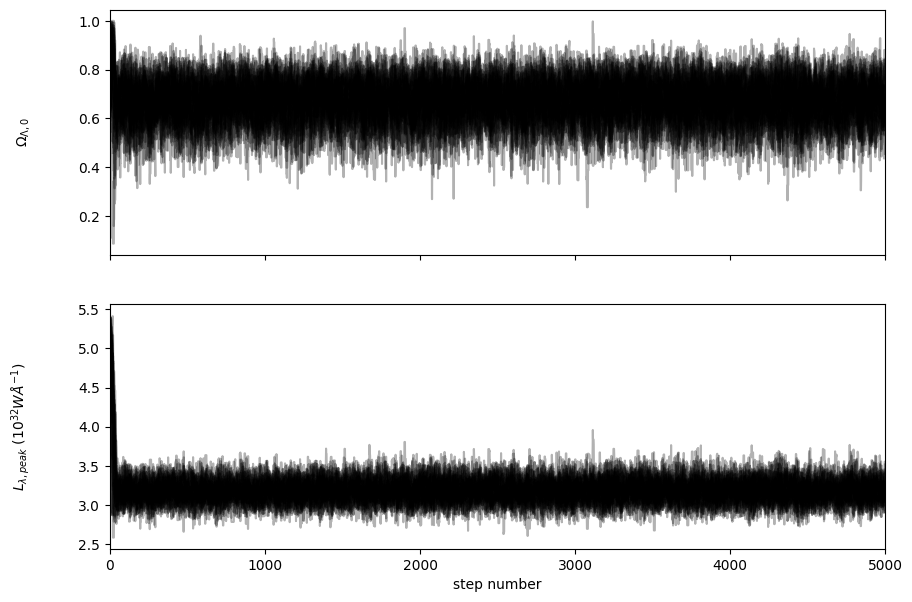

In [176]:
ndiscard = 100  #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["${Ω_{Λ,0}}$", "${L_{λ, peak}}$ ${(10^{32} W Å^{-1})}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

print(sampler.get_autocorr_time())

# Covariance plots

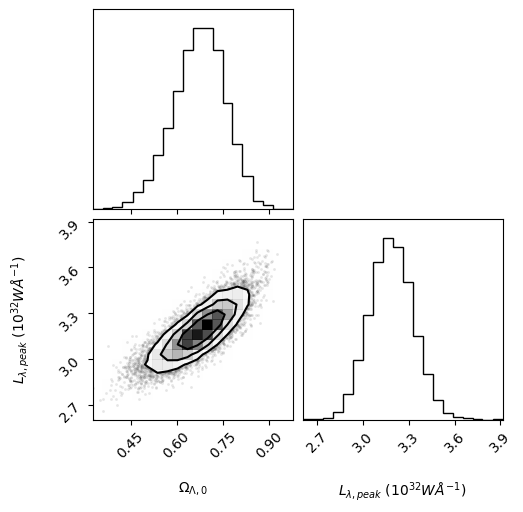

In [177]:

fig = corner.corner(
    flat_samples, labels = labels
)
plt.savefig("corner.png")

In [178]:


for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [34, 50, 68])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]}, {q[0]}, {q[1]}")

${Ω_{Λ,0}}$: 0.675544115884926, 0.035396019419040914, 0.039304367221106196
${L_{λ, peak}}$ ${(10^{32} W Å^{-1})}$: 3.181431533390535, 0.058246085646070256, 0.0670273464492479
